## Setup and Dependencies

In [1]:
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf
import datetime as dt

## Model Setup

In [2]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


## Model Execution

Hyperparameters: DSGE model type, productivity calibration period, window start, window end, strategy direction, signal lag

In [3]:
class Modifications():
    def __init__(self):
        self.months_in_quarter = 3

    def convert_years_to_quarters(self, length_years):
        return length_years * 4
    
    def convert_years_to_months(self, length_years):
        return length_years * 12

    def get_shifted_date(self, date_input, date_offset_months, direction="backwards"):
        if direction == "backwards":
            date_offset_months *= -1
        
        shifted_date = (
            ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) + pd.tseries.offsets.DateOffset(months=date_offset_months)) 
            + pd.tseries.offsets.BMonthEnd()
        ).date()
    
        return shifted_date
    
    def add_buffer_for_start_offset(self, offset_months):
        return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

In [4]:
class Data(Modifications):
    def  __init__(self, data_length_years_max, horizon_start_in, horizon_end_in):
        Modifications.__init__(self)
        self.data_length_years_max = data_length_years_max
        self.data_length_quarters_max = self.convert_years_to_quarters(self.data_length_years_max)
        self.data_length_months_max = self.convert_years_to_months(self.data_length_years_max)
        
        self.horizon_start_in = horizon_start_in
        self.horizon_end_in = horizon_end_in
        self.horizon_start = self.convert_str_date_to_dt(self.horizon_start_in)
        self.horizon_end = self.convert_str_date_to_dt(self.horizon_end_in)
        self.date_start_gdp = self.get_shifted_date(self.horizon_start, self.add_buffer_for_start_offset(self.data_length_months_max)) # Data starts 10 years prior to window start
        self.date_start_prod = self.get_shifted_date(self.date_start_gdp, self.months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
        self.date_end_prod = self.get_shifted_date(self.horizon_end, self.months_in_quarter) # Data ends one quarter before window end as the final forecast must be of the window end date
        # self.horizon_start_prod = self.get_shifted_date(self.horizon_start, self.months_in_quarter) # Window starts one quarter prior to GDP data for next-period forecasting
        self.date_end_asset = self.get_shifted_date(self.horizon_end, self.months_in_quarter, "forwards") + pd.tseries.offsets.DateOffset(days=1) # end date in yahoo finance query is exclusive so extend by 1 day

        self.prod = self.pull_data_productivity()
        self.gdp = self.pull_data_gdp()
        self.asset = self.pull_asset()
        self.holidays = self.get_holidays()

    def convert_str_date_to_dt(self, date_in):
        return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

    def convert_fred_index_to_qe(self, index_dates):
        return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]
    
    # Non-farm business labor productivity index
    def pull_data_productivity(self):
        prod = pdr.DataReader("OPHNFB", "fred", start=self.date_start_prod, end=self.date_end_prod)
        prod_index_name = prod.index.name
        prod.index = self.convert_fred_index_to_qe(prod.index)
        prod.index.name = prod_index_name
        prod = prod.dropna()
        
        return prod

    # Real GDP
    def pull_data_gdp(self):
        gdp = pdr.DataReader("GDPC1", "fred", start=self.date_start_gdp, end=self.horizon_end)
        gdp_index_name = gdp.index.name
        gdp.index = self.convert_fred_index_to_qe(gdp.index)
        gdp.index.name = gdp_index_name
        gdp = gdp.dropna()
        
        return gdp

    # S&P 500
    def pull_asset(self):
        asset_ser = yf.Ticker("^GSPC").history(start=self.horizon_start, end=self.date_end_asset)["Close"]

        asset_ser_name = asset_ser.index.name
        asset_ser.index = asset_ser.index.date
        asset_ser.index.name = asset_ser_name
        
        return asset_ser

    def get_holidays(self):
        cal_us = USFederalHolidayCalendar()
        holidays = cal_us.holidays(start=self.horizon_start, end=self.date_end_asset) # holiday date range for the window considered for the country linked to the asset

        return holidays

In [42]:
class Model(Modifications):
    def __init__(self, model_type, prod, gdp, asset, holidays):
        Modifications.__init__(self)
        self.model_type = model_type
        self.model = self.load_model(self.model_type)
        self.prod = prod
        self.gdp = gdp
        self.asset = asset
        self.holidays = holidays

        self.latest_quarters_dict = {}
        self.output_forecasts_dict = {}
        self.latest_quarters_gdp_dict = {}
        self.outputs_realised_dict = {}

    def load_model(self, model_type):
        model = yaml_import(f"yamlDSGE/{model_type}.yaml")

        return model

    def generate_signals(self, data_length_years, window_gdp_start, window_gdp_end):
        assert len(self.prod) == len(self.gdp)

        data_length_quarters = self.convert_years_to_quarters(data_length_years)
        data_length_months = self.convert_years_to_months(data_length_years)

        # Check the window and preceding data are in bounds of overall productivity and GDP data
        earliest_datapoint_gdp = self.get_shifted_date(window_gdp_start, data_length_months)
        assert earliest_datapoint_gdp >= self.gdp.index[0], f"Outside bounds: {earliest_datapoint_gdp} !>= {self.gdp.index[0]}"

        earliest_datapoint_prod = self.get_shifted_date(earliest_datapoint_gdp, self.months_in_quarter)
        assert earliest_datapoint_prod >= self.prod.index[0], f"Outside bounds: {earliest_datapoint_prod} !>= {self.prod.index[0]}"

        assert window_gdp_end <= self.gdp.index[-1], f"Outside bounds: {window_gdp_end} !<= {self.gdp.index[-1]}"
        
        latest_datapoint_prod = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        assert latest_datapoint_prod <= self.prod.index[-1], f"Outside bounds: {latest_datapoint_prod} !<= {self.prod.index[-1]}"

        # Generate output forecasts
        prod_index_name = self.prod.index.name
        window_prod_start = self.get_shifted_date(window_gdp_start, self.months_in_quarter)
        window_prod_end = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        window_prod = self.prod[(self.prod.index >= window_prod_start) & (self.prod.index <= window_prod_end)]
        print("\nwindow_prod:\n")
        print(window_prod)
        
        latest_quarters = []
        output_forecasts = []
        for q in window_prod.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_dict.keys():
                latest_quarters.append(self.latest_quarters_dict[q_key])
                output_forecasts.append(self.output_forecasts_dict[q_key])
                print(f"Reading IRF forecast as of {q} with {data_length_years} years of calibration")
            else:
                prod_data = self.prod[(self.prod.index >= self.get_shifted_date(q, data_length_months)) & (self.prod.index <= q)]
                assert len(prod_data.index) == data_length_quarters + 1
                
                prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
                # prod_cycle.plot()
                
                a_hat = prod_cycle
                a = a_hat
                a_lag = a.shift()
                
                y = a.iloc[1:]
                X = a_lag.iloc[1:].values
                
                ar1 = OLS(y.values, X).fit()
                
                rho_hat = ar1.params[0]
                print(f"Estimated rho: {rho_hat:.3f}")
            
                eps_hat = pd.Series(
                    ar1.resid,
                    index=y.index,
                    name="tfp_shock"
                )
                # eps_hat.plot()
                
                latest_quarter = eps_hat.index[-1]
                latest_shock = eps_hat.iloc[-1]
                
                print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")
            
                # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
                self.model.set_calibration(rho=rho_hat)
                # print(model.calibration.flat)
            
                #dr = time_iteration(model)
                dr = perturb(self.model, order=1)
                
                irf = response(self.model, dr, 'e_z', T=10, impulse=float(latest_shock))
                
                # plt.figure(figsize=(8,4))
                # plt.subplot(221)
                # plt.plot(irf.sel(V='z'))
                # plt.title('Productivity')
                # plt.grid()
                # plt.subplot(222)
                # plt.plot(irf.sel(V='y'))
                # plt.title('Output')
                # plt.grid()
                # plt.subplot(223)
                # plt.plot(irf.sel(V='i'))
                # plt.title('Investment')
                # plt.grid()
                # plt.subplot(224)
                # plt.plot(irf.sel(V='c'))
                # plt.title('Consumption')
                # plt.grid()
                # plt.tight_layout()
                
                irf_output = np.array(irf.sel(V='y'))
                
                irf_output = [(x - 1) for x in irf_output]
                output_forecast = irf_output[2]
                print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
                
                self.latest_quarters_dict[q_key] = latest_quarter
                latest_quarters.append(latest_quarter)
                self.output_forecasts_dict[q_key] = output_forecast
                output_forecasts.append(output_forecast)
        
        output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
        output_forecasts_ser.name = "output_forecast"
        output_forecasts_ser.index.name = prod_index_name
        output_forecasts_df = output_forecasts_ser.to_frame()
        # output_forecasts_df

        # Obtain realised output
        gdp_index_name = self.gdp.index.name
        window_gdp = self.gdp[(self.gdp.index >= window_gdp_start) & (self.gdp.index <= window_gdp_end)]
        print("\window_gdp:\n")
        print(window_gdp)
        
        latest_quarters_gdp = []
        outputs_realised = []
        for q in window_gdp.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_gdp_dict.keys():
                latest_quarters_gdp.append(self.latest_quarters_gdp_dict[q_key])
                outputs_realised.append(self.outputs_realised_dict[q_key])
                print(f"Reading realised value as of {q} with {data_length_years} years of calibration")
            else:
                gdp_data = self.gdp[(self.gdp.index >= self.get_shifted_date(q, data_length_months)) & (self.gdp.index <= q)]
                assert len(gdp_data.index) == data_length_quarters + 1
            
                gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
                output_gap = gdp_cycle
                latest_quarter_gdp = output_gap.last_valid_index()
                output_realised = output_gap.iloc[-1]
                print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
                
                self.latest_quarters_gdp_dict[q_key] = latest_quarter_gdp
                latest_quarters_gdp.append(latest_quarter_gdp)
                self.outputs_realised_dict[q_key] = output_realised
                outputs_realised.append(output_realised)
        
        outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
        outputs_realised_ser.name = "output_realised"
        outputs_realised_ser.index.name = gdp_index_name
        outputs_realised_df = outputs_realised_ser.to_frame()
        # outputs_realised_df

        # Prepare signals
        signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
        output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
        signals = outputs_realised_df.join(output_forecasts_mod_df)
        
        def determine_pos(row, direction):
            if row["output_forecast"] > row["output_realised"]:
                pos = 1
            elif row["output_forecast"] < row["output_realised"]:
                pos = -1
            else:
                pos = 0
        
            if direction == "mr":
                pos *= -1
            
            return pos
        
        signals["pos_mom"] = signals.apply(determine_pos, axis=1, direction="mom")
        signals["pos_mr"] = signals.apply(determine_pos, axis=1, direction="mr")
        # signals

        return signals

    def summarise_results(self, pos, pnl, strategy_type):
        fig_pos, ax_pos = plt.subplots(figsize=(12, 6))
        pos.plot(ax=ax_pos, grid=True)
        plt.close(fig_pos)
        
        fig_pnl_cumsum, ax_pnl_cumsum = plt.subplots(figsize=(12, 6))
        pnl.cumsum().plot(ax=ax_pnl_cumsum, grid=True)
        plt.close(fig_pnl_cumsum)

        pnl_sum = pnl.sum()
        pnl_mean = pnl.mean()
        pnl_std = pnl.std()
        sr_daily = pnl_mean / pnl_std
        sr_annual = sr_daily * np.sqrt(252)

        results = {
            "fig_pos_" + strategy_type: fig_pos,
            "fig_pnl_cumsum_" + strategy_type: fig_pnl_cumsum,
            "pnl_sum_" + strategy_type: pnl_sum,
            "pnl_mean_" + strategy_type: pnl_mean,
            "pnl_std_" + strategy_type: pnl_std,
            "sr_daily_" + strategy_type: sr_daily,
            "sr_annual_" + strategy_type: sr_annual
        }
        
        return results
    
    def run_strategy(self, signals, signal_lag, window_gdp_start, window_gdp_end, leverage):
        # Delay signals by a particular number of business days to account for lag in GDP and productivity data availability
        signals_actual = signals.copy()
        signals_actual.index += pd.offsets.CustomBusinessDay(n=signal_lag, holidays=self.holidays)
        
        date_end_asset = self.get_shifted_date(window_gdp_end, self.months_in_quarter, "forwards")
        asset_ser = self.asset[(self.asset.index >= window_gdp_start) & (self.asset.index <= date_end_asset)]
        asset_ret_ser = asset_ser.pct_change()
        asset_ret_ser.name = "Return"

        asset_ret_df = asset_ret_ser.to_frame()
        asset_ret_df = asset_ret_df.join(signals_actual[["pos_mom", "pos_mr"]]).ffill().fillna(0)

        asset_ret_lagged_df = asset_ret_df[["pos_mom", "pos_mr"]].shift()
        pnl = asset_ret_df[["Return"]].join(asset_ret_lagged_df).fillna(0)
        pnl["pnl_mom"] = pnl["Return"] * pnl["pos_mom"] * leverage
        pnl["pnl_mr"] = pnl["Return"] * pnl["pos_mr"] * leverage

        results_mom = self.summarise_results(asset_ret_df["pos_mom"], pnl["pnl_mom"], "mom")
        results_mr = self.summarise_results(asset_ret_df["pos_mr"], pnl["pnl_mr"], "mr")

        return {"signals_actual": signals_actual} | results_mom | results_mr#| {"pnl_mom": pnl["pnl_mom"], "pnl_mr": pnl["pnl_mr"]}

In [6]:
data_20y_19991231_20250930 = Data(10, "1999-12-31", "2025-09-30")

In [43]:
rbc = Model(
    "rbc", 
    data_20y_19991231_20250930.prod, 
    data_20y_19991231_20250930.gdp, 
    data_20y_19991231_20250930.asset,
    data_20y_19991231_20250930.holidays
)

In [44]:
model_types = ["rbc"]
data_lengths = [5, 10, 20]
windows = [
    [dt.date(1999, 12, 31), dt.date(2025, 9, 30)],
    # [dt.date(1999, 12, 31), dt.date(2007, 12, 31)],
    # [dt.date(2007, 12, 31), dt.date(2009, 12, 31)],
    # [dt.date(2009, 12, 31), dt.date(2019, 12, 31)],
    # [dt.date(2019, 12, 31), dt.date(2022, 12, 31)],
    # [dt.date(2022, 12, 31), dt.date(2025, 9, 30)],
]
signal_lags = [10, 20, 30]
leverage_cases = [1, 2]

results = {}
for model_type in model_types:
    for data_length in data_lengths:
        for window in windows:
            for signal_lag in signal_lags:
                for leverage in leverage_cases:
                    if not ((data_length == 20) & (window[0] < dt.date(2009, 12, 31))): # GDP data is unavailable before 1989-12-29 so avoid sourcing data before then
                        signals = rbc.generate_signals(data_length, window[0], window[1])
                        strategy = rbc.run_strategy(signals, signal_lag, window[0], window[1], leverage)
                        
                        key = model_type + "_" + str(data_length) + "calib_" + str(window[0]) + "_" + str(window[1]) + "_" + str(signal_lag) + "lag"
                        if leverage > 1:
                            key += str(leverage) + "lev"
                        
                        results[key] = {"signals": signals, "strategy": strategy}


window_prod:

             OPHNFB
DATE               
1999-09-30   70.469
1999-12-31   71.516
2000-03-31   71.222
2000-06-30   72.657
2000-09-29   72.587
...             ...
2024-06-28  114.947
2024-09-30  115.989
2024-12-31  116.394
2025-03-31  116.127
2025-06-30  117.319

[104 rows x 1 columns]
Estimated rho: 0.746
Estimated TFP shock for 1999-09-30: 0.0038
10 [0.00378041]
Next period IRF forecast as of 1999-09-30: 0.00004
Estimated rho: 0.716
Estimated TFP shock for 1999-12-31: 0.0089
10 [0.00891529]
Next period IRF forecast as of 1999-12-31: 0.00697
Estimated rho: 0.586
Estimated TFP shock for 2000-03-31: -0.0067
10 [-0.00668182]
Next period IRF forecast as of 2000-03-31: -0.01405
Estimated rho: 0.461
Estimated TFP shock for 2000-06-30: 0.0107
10 [0.01069896]
Next period IRF forecast as of 2000-06-30: 0.01003
Estimated rho: 0.407
Estimated TFP shock for 2000-09-29: -0.0037
10 [-0.00365668]
Next period IRF forecast as of 2000-09-29: -0.01004
Estimated rho: 0.365
Estimated TFP shock

In [45]:
pnls = []
srs = []
for strategy in results.keys():
    pnls.append([strategy + "_mom", results[strategy]["strategy"]["pnl_sum_mom"]])
    pnls.append([strategy + "_mr", results[strategy]["strategy"]["pnl_sum_mr"]])
    srs.append([strategy + "_mom", results[strategy]["strategy"]["sr_annual_mom"]])
    srs.append([strategy + "_mr", results[strategy]["strategy"]["sr_annual_mr"]])

pnls_sorted = sorted(pnls, key=lambda x: x[1], reverse=True)
srs_sorted = sorted(srs, key=lambda x: x[1], reverse=True)

In [46]:
pnls_sorted

[['rbc_10calib_1999-12-31_2025-09-30_30lag2lev_mr', 2.3268963552108834],
 ['rbc_5calib_1999-12-31_2025-09-30_30lag2lev_mr', 1.9655817727863252],
 ['rbc_10calib_1999-12-31_2025-09-30_20lag2lev_mr', 1.841518941006284],
 ['rbc_5calib_1999-12-31_2025-09-30_20lag2lev_mr', 1.280012629182451],
 ['rbc_10calib_1999-12-31_2025-09-30_30lag_mr', 1.1634481776054417],
 ['rbc_10calib_1999-12-31_2025-09-30_10lag2lev_mr', 1.0168942265775485],
 ['rbc_5calib_1999-12-31_2025-09-30_30lag_mr', 0.9827908863931626],
 ['rbc_10calib_1999-12-31_2025-09-30_20lag_mr', 0.920759470503142],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag2lev_mr', 0.7428152268909516],
 ['rbc_5calib_1999-12-31_2025-09-30_20lag_mr', 0.6400063145912255],
 ['rbc_10calib_1999-12-31_2025-09-30_10lag_mr', 0.5084471132887742],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag_mr', 0.3714076134454758],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag_mom', -0.3714076134454758],
 ['rbc_10calib_1999-12-31_2025-09-30_10lag_mom', -0.5084471132887742],
 ['rbc_5calib_19

In [47]:
srs_sorted

[['rbc_10calib_1999-12-31_2025-09-30_30lag_mr', 0.2322485894971032],
 ['rbc_10calib_1999-12-31_2025-09-30_30lag2lev_mr', 0.2322485894971032],
 ['rbc_5calib_1999-12-31_2025-09-30_30lag_mr', 0.19617960086156677],
 ['rbc_5calib_1999-12-31_2025-09-30_30lag2lev_mr', 0.19617960086156677],
 ['rbc_10calib_1999-12-31_2025-09-30_20lag_mr', 0.1836739053033938],
 ['rbc_10calib_1999-12-31_2025-09-30_20lag2lev_mr', 0.1836739053033938],
 ['rbc_5calib_1999-12-31_2025-09-30_20lag_mr', 0.1276646025919794],
 ['rbc_5calib_1999-12-31_2025-09-30_20lag2lev_mr', 0.1276646025919794],
 ['rbc_10calib_1999-12-31_2025-09-30_10lag_mr', 0.10129898806811238],
 ['rbc_10calib_1999-12-31_2025-09-30_10lag2lev_mr', 0.10129898806811238],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag_mr', 0.07399561743297493],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag2lev_mr', 0.07399561743297493],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag_mom', -0.07399561743297493],
 ['rbc_5calib_1999-12-31_2025-09-30_10lag2lev_mom', -0.07399561743297493],
 [

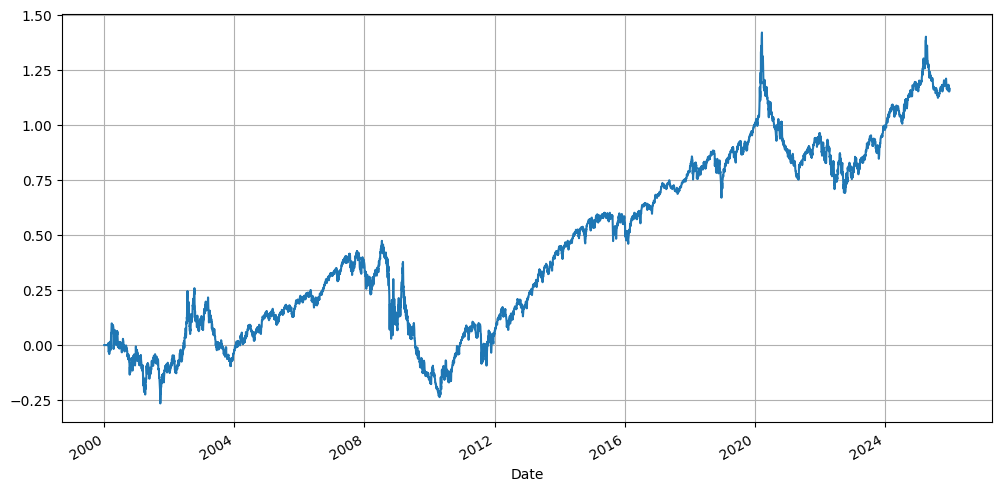

In [48]:
results["rbc_10calib_1999-12-31_2025-09-30_30lag"]["strategy"]["fig_pnl_cumsum_mr"]

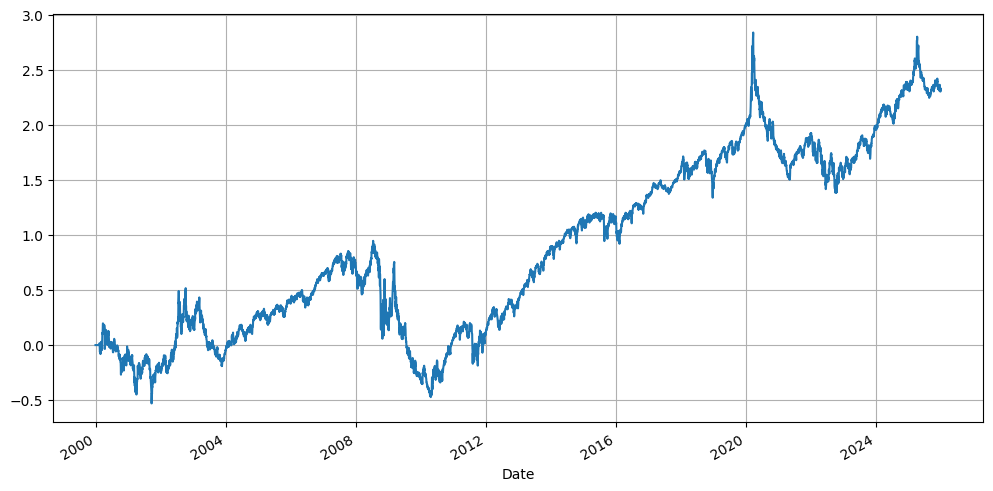

In [49]:
results["rbc_10calib_1999-12-31_2025-09-30_30lag2lev"]["strategy"]["fig_pnl_cumsum_mr"]

In [50]:
# check if doubling down upon subsequent maintained signal works better

In [23]:
asset_ser = data_20y_19991231_20250930.asset

In [26]:
asset_ret_ser = asset_ser.pct_change().fillna(0)
asset_ret_ser.name = "Return"

In [28]:
asset_ret_ser.sum()

2.0262566792516465

In [36]:
asset_ret_ser.mean() / asset_ret_ser.std() * np.sqrt(252)

0.40322023487957226

<Axes: xlabel='Date'>

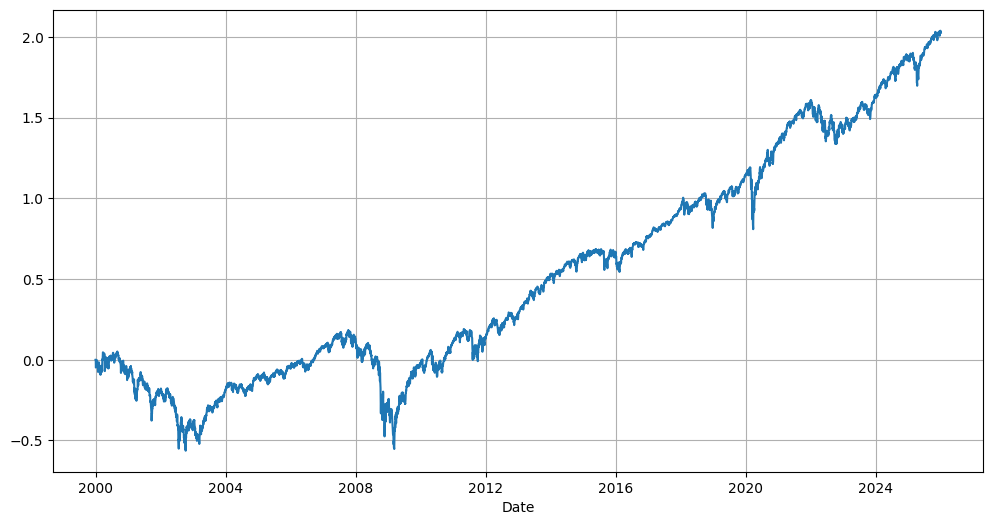

In [41]:
asset_ret_ser.cumsum().plot(figsize=(12, 6), grid=True)